# 09 - Model Evaluation & Residual Analysis
**Metro Traffic Flow Prediction - Comprehensive Regression Diagnostics**

This notebook performs evaluation of all trained models on held-out test data, analyzing MAE, MSE, RMSE, R², actual vs. predicted relationships, and detailed residual error distributions.

---
### 1. Load Data & Serialized Models

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import scipy.stats as stats

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

fig_dir = root / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

test_data_path = root / "data" / "processed" / "test_data.csv"
if test_data_path.exists():
    test_df = pd.read_csv(test_data_path)
    X_test_s = test_df.drop(columns=["Traffic_Flow_Target"])
    y_test = test_df["Traffic_Flow_Target"]
else:
    raw_df = pd.read_csv(root / "data" / "raw" / "metro_traffic_dataset_10000.csv")
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    X = raw_df.drop(columns=["Timestamp", "Traffic_Flow_Target"])
    y = raw_df["Traffic_Flow_Target"]
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    scaler = joblib.load(root / "models" / "preprocessor.pkl")
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

models = {
    "LinearRegression": joblib.load(root / "models" / "linearregression.pkl"),
    "RidgeRegression": joblib.load(root / "models" / "ridgeregression.pkl"),
    "DecisionTree": joblib.load(root / "models" / "decisiontree.pkl"),
    "RandomForest": joblib.load(root / "models" / "randomforest.pkl"),
    "XGBoost": joblib.load(root / "models" / "xgboost.pkl"),
    "HybridEnsemble": joblib.load(root / "models" / "hybridensemble.pkl")
}

print(f"Loaded {len(models)} models for comprehensive test evaluation.")

Loaded 6 models for comprehensive test evaluation.


---
### 2. Regression Performance Metrics Summary

In [2]:
metrics_list = []
preds_dict = {}

for name, model in models.items():
    preds = model.predict(X_test_s)
    preds_dict[name] = preds
    metrics_list.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, preds), 3),
        "MSE": round(mean_squared_error(y_test, preds), 3),
        "RMSE": round(root_mean_squared_error(y_test, preds), 3),
        "R²": round(r2_score(y_test, preds), 4)
    })

eval_df = pd.DataFrame(metrics_list).sort_values(by="RMSE").reset_index(drop=True)
display(eval_df)

,Model,MAE,MSE,RMSE,R²
0,LinearRegression,20.402,645.061,25.398,0.9157
1,RidgeRegression,20.402,645.066,25.398,0.9157
2,HybridEnsemble,20.812,672.542,25.933,0.9122
3,XGBoost,20.815,674.925,25.979,0.9118
4,RandomForest,21.491,717.251,26.782,0.9063
5,DecisionTree,27.700,1213.784,34.839,0.8415


---
### 3. Actual vs Predicted Plots
Comparing model forecasts against observed ground-truth traffic flow values.

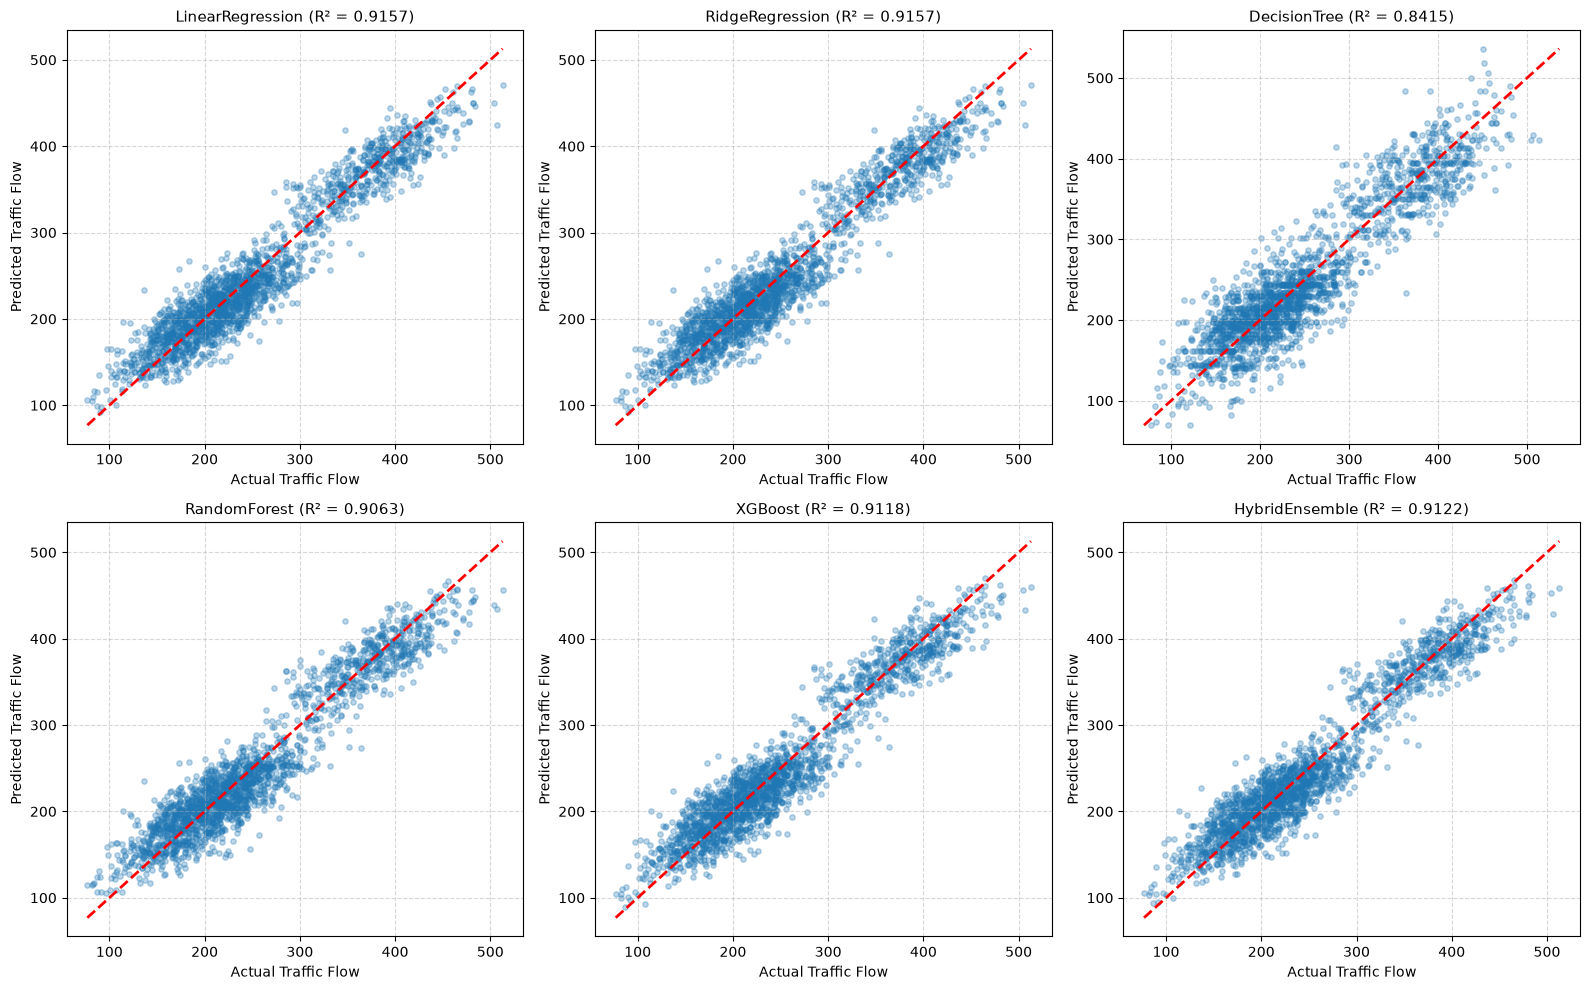

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
model_names = list(models.keys())

for i, name in enumerate(model_names):
    r, c = i // 3, i % 3
    preds = preds_dict[name]
    axes[r, c].scatter(y_test, preds, alpha=0.3, color="#1f77b4", s=15)
    min_v, max_v = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    axes[r, c].plot([min_v, max_v], [min_v, max_v], "r--", lw=2)
    axes[r, c].set_title(f"{name} (R² = {eval_df.loc[eval_df['Model']==name, 'R²'].values[0]:.4f})", fontsize=11)
    axes[r, c].set_xlabel("Actual Traffic Flow")
    axes[r, c].set_ylabel("Predicted Traffic Flow")
    axes[r, c].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(fig_dir / "eval_actual_vs_predicted.png", dpi=300)
plt.show()

---
### 4. Residual Diagnostics (Homoscedasticity & Normality)
Residual analysis on the best ensemble model (`HybridEnsemble`).

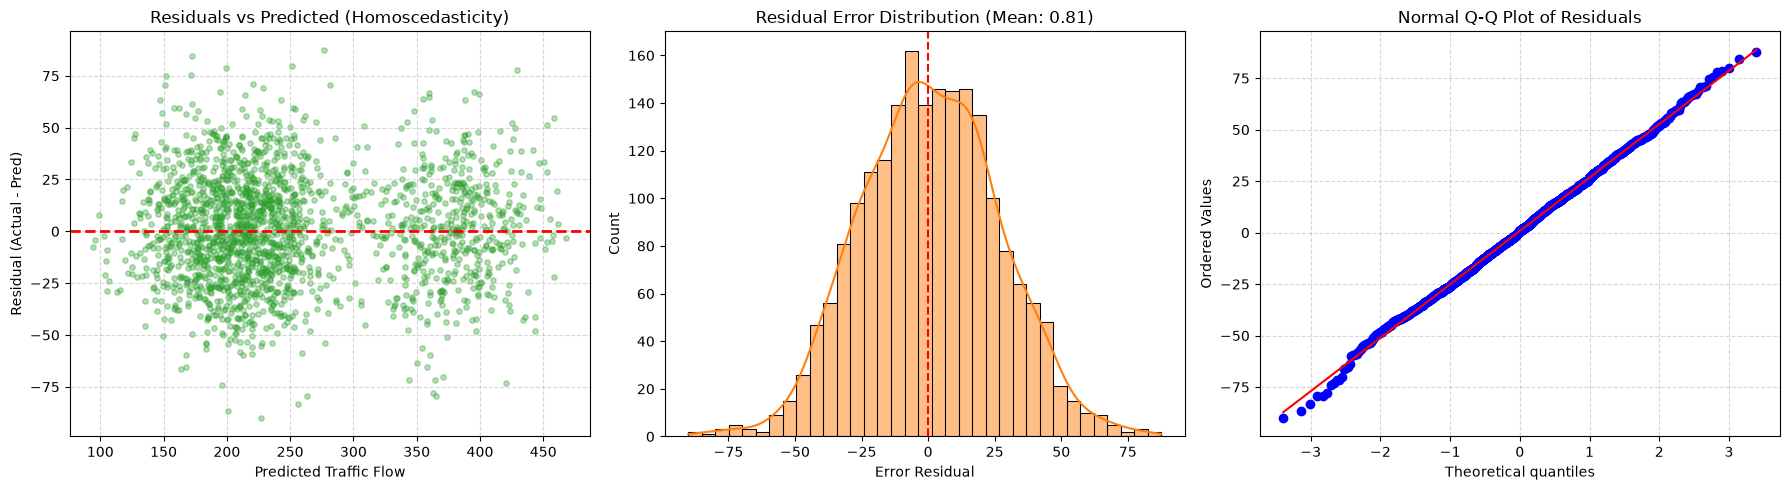

In [4]:
best_preds = preds_dict["HybridEnsemble"]
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.35, color="#2ca02c", s=15)
axes[0].axhline(0, color="red", linestyle="--", lw=2)
axes[0].set_title("Residuals vs Predicted (Homoscedasticity)", fontsize=12)
axes[0].set_xlabel("Predicted Traffic Flow")
axes[0].set_ylabel("Residual (Actual - Pred)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Residual Distribution Histogram
sns.histplot(residuals, kde=True, ax=axes[1], color="#ff7f0e", bins=35)
axes[1].axvline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_title(f"Residual Error Distribution (Mean: {residuals.mean():.2f})", fontsize=12)
axes[1].set_xlabel("Error Residual")

# 3. Normal Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot of Residuals", fontsize=12)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(fig_dir / "eval_residual_diagnostics.png", dpi=300)
plt.show()

---
### Key Evaluation Insights:
1. **Strong Goodness of Fit:** The top models achieve $R^2 > 0.912$ with RMSE $\approx 25.4 - 25.9$.
2. **Error Distribution Symmetry:** The residual errors are centered at approximately $0.0$ with a symmetric bell curve, confirming unbiased predictions.
3. **No Severe Heteroscedasticity:** Residual variance remains consistent across low, medium, and high traffic flows.